# 03 — Entity Extraction from Complaint Narratives

Pulls structured facts (dollar amounts, dates, companies) out of free-text credit reporting complaint narratives. Uses spaCy's pretrained NER as a baseline, extended with pattern-based extraction for financial-domain entities spaCy doesn't cover well (dollar amounts).

Complements Notebook 02's LDA approach with a different extraction task: instead of latent themes, this pulls concrete, structured facts that can feed directly into Notebook 04 as classifier features.

**Question this notebook asks:** can complaint narratives reveal structured, extractable facts (companies, dollar amounts, dates) beyond what's already in the dataset's structured fields? Notebook 04 picks up from here to ask whether any of these extracted signals actually improve prediction.


In [1]:
from google.colab import drive
drive.mount('/content/drive/')

import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/ANLP_portfolio/")


Mounted at /content/drive/


In [2]:
!pip install spacy -q
!python -m spacy download en_core_web_sm -q


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=DeprecationWarning)


"""
`en_core_web_sm` is spaCy's small pretrained English pipeline — trained on
 general news/web text, not on financial or legal language specifically.
 Loading it gives tokenization, part-of-speech tagging, and named entity
recognition out of the box; this notebook uses the entity recognition
  piece (`doc.ents`) to extract entity types like ORG, DATE, and MONEY from
  narrative text. Being general-domain is exactly why the dollar-amount regex
  below exists as a backup — spaCy's own MONEY entity type isn't reliable
  on this dataset's specific formatting conventions.

"""


nlp = spacy.load("en_core_web_sm")

DATA_PATH = "data/complaints_credit_reporting.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
print(df.shape)
print(df['Consumer complaint narrative'].notna().mean())  # should be 1.0 -- confirmed in 01_eda


(400445, 16)
1.0


## Deduplicating Narratives

Same rationale as Notebook 02: 01_eda found 48.6% of narratives in this dataset are exact duplicates, concentrated in a small number of near-identical dispute-letter templates. Running NER on every occurrence of the same template narrative is wasted compute — an exact duplicate produces the exact same entities every time — and inflates any summary statistics about "how often complaints mention a dollar amount" into "how often this one template (which happens to mention a dollar amount) gets repeated." Deduplicating first, then extracting entities once per unique narrative.

In [3]:
before = len(df)
df = df.drop_duplicates(subset='Consumer complaint narrative').reset_index(drop=True)
after = len(df)

print(f"Rows before dedup: {before:,}")
print(f"Rows after dedup:  {after:,}")

narratives = df['Consumer complaint narrative']


Rows before dedup: 400,445
Rows after dedup:  164,533


## A Constraint Worth Knowing Before Running NER: CFPB's Own Redaction

Notebook 02's sample narratives showed CFPB masks personally identifying details with `XXXX` before publishing — including exact dates (`Date Opened: XX/XX/XXXX`) and account numbers (`Account XXXX. XXXX`). This directly limits what NER can recover here:

- **Dates are mostly unrecoverable.** Since the actual date digits are replaced with `XXXX`, spaCy's DATE entity recognizer has nothing to extract in the majority of cases — expect very low DATE hit rates, not a sign the model is failing.
- **Dollar amounts survive redaction and are extractable.** CFPB's convention wraps amounts in curly braces (e.g., `{$150.00}`), but doesn't mask the digits — the regex approach below should catch these reliably.
- **Company/bureau names survive redaction and are extractable.** Names like Experian, TransUnion, Equifax, and specific creditors appear in plain text — spaCy's ORG entity type should perform reasonably well here.

Worth confirming this pattern empirically below rather than just assuming it, but it sets expectations: this notebook should be read as "extract what CFPB's own redaction leaves extractable" (dollar amounts, company names) rather than a full extraction of every fact type.

## spaCy NER on a Sample Narrative

Before extracting entities at scale, checking what spaCy actually recognizes on one narrative — a quick sanity check that the model loaded correctly and produces sensible entity types before running it across the full corpus.

In [4]:
sample = narratives.iloc[0]
doc = nlp(sample)

for ent in doc.ents:
    print(f"{ent.text:<30} {ent.label_}")


## Pattern-Based Extraction: Dollar Amounts

spaCy's MONEY entity is inconsistent on informally-written amounts (`$1,200`, `1200 dollars`, `$1.2k`), and CFPB's `{$1,200.00}` bracket convention isn't standard MONEY-entity phrasing either. A regex pass is more reliable here — matching `$` followed by digits works regardless of surrounding brackets, since it scans for the pattern anywhere in the text rather than requiring an exact structural match.

In [5]:
DOLLAR_PATTERN = re.compile(r'\$[\d,]+(?:\.\d{2})?')

def extract_dollar_amounts(text):
    return [m.group() for m in DOLLAR_PATTERN.finditer(text)]

extract_dollar_amounts(sample)


[]

## Confirming the Redaction Pattern Empirically

Before extracting entities across the full corpus, checking the hypothesis above on a larger sample: DATE hit rate should be low (redacted), MONEY/dollar-regex and ORG hit rates should be meaningfully higher (not redacted).

In [6]:
check_sample = narratives.sample(200, random_state=42)

has_date_ent = 0
has_org_ent = 0
has_dollar_regex = 0

for text in check_sample:
    doc = nlp(text)
    if any(e.label_ == 'DATE' for e in doc.ents):
        has_date_ent += 1
    if any(e.label_ == 'ORG' for e in doc.ents):
        has_org_ent += 1
    if extract_dollar_amounts(text):
        has_dollar_regex += 1

n = len(check_sample)
print(f"Narratives with a spaCy DATE entity:   {has_date_ent}/{n} ({has_date_ent/n:.1%})")
print(f"Narratives with a spaCy ORG entity:    {has_org_ent}/{n} ({has_org_ent/n:.1%})")
print(f"Narratives with a regex dollar amount: {has_dollar_regex}/{n} ({has_dollar_regex/n:.1%})")


Narratives with a spaCy DATE entity:   94/200 (47.0%)
Narratives with a spaCy ORG entity:    155/200 (77.5%)
Narratives with a regex dollar amount: 63/200 (31.5%)


## Confirming (and Correcting) the Redaction Hypothesis

The predicted ordering — DATE lowest, ORG and dollar amounts both higher — only partly holds. Actual results:

| Entity type | Hit rate |
|---|---|
| ORG | 77.5% |
| DATE | 47.0% |
| Dollar amount (regex) | 31.5% |

**ORG is confirmed as expected** — highest hit rate, consistent with company/bureau names surviving CFPB's redaction untouched.

**DATE is not nearly as suppressed as predicted.** At 47%, it sits in the middle, not at the bottom. The likely explanation: spaCy's DATE entity type isn't limited to specific calendar dates — it also catches relative/descriptive time language ("last month," "over a year," "within 30 days," "since 2019"), which survives redaction even when exact dates get masked as `XX/XX/XXXX`. The redaction hypothesis was right that *specific* dates are suppressed, but wrong to predict that would suppress the DATE entity type overall — narratives are full of temporal language that isn't a specific date.

**Dollar amounts are the least common of the three, and that's likely just a real property of the dataset, not a redaction effect.** Only about a third of narratives cite an explicit dollar figure — plenty of credit-reporting complaints (e.g., disputing an inquiry, requesting an account be removed) don't necessarily involve a specific dollar amount at all. Nothing here suggests dollar amounts are being redacted or missed; the extraction method itself isn't in question, just the underlying base rate.

**Revised takeaway:** redaction cleanly explains why ORG outperforms DATE and dollar-amount extraction on *specificity*, but the actual hit-rate ordering is driven by a mix of redaction and genuine differences in what complainants choose to mention — worth stating precisely rather than forcing the numbers to match the original prediction.

## Batch Extraction Across the Full Corpus

Using `nlp.pipe()` for batched processing rather than looping `nlp(text)` one at a time — meaningfully faster across 100k+ narratives. Building one row of extracted entities per narrative.

`nlp.pipe()` processes texts in batches internally rather than one document at a time, which is meaningfully faster at this corpus size (164,533 narratives) -- an earlier attempt using `n_process` for multiprocessing hung reliably in Colab, so this uses single-process batching instead, trading some speed for reliability.

In [9]:
# Checkpointed batch entity extraction.
#
# The previous attempt ran for 45+ minutes and completed successfully in-memory,
# but the Colab session expired before the final df.to_csv() step ran -- losing
# all of it, since nothing was written to disk until the very end.
#
# This version fixes that by saving each chunk's results to its own JSON file as
# soon as that chunk finishes, and skipping any chunk that already has a saved
# checkpoint. If the session disconnects again mid-run, rerunning this cell picks
# up exactly where it left off instead of starting over -- worst case, one
# in-progress chunk (~5-6 minutes) is lost, not the whole 45-minute run.

import os
import json
import time
from tqdm.auto import tqdm

def extract_entities_batch(texts, batch_size=200):
    results = []
    docs = nlp.pipe(
        texts,
        batch_size=batch_size,
        disable=["tagger", "parser", "lemmatizer", "attribute_ruler"],
    )
    for text, doc in zip(texts, docs):
        results.append({
            'orgs': [e.text for e in doc.ents if e.label_ == 'ORG'],
            'money_ner': [e.text for e in doc.ents if e.label_ == 'MONEY'],
            'money_regex': extract_dollar_amounts(text),
            'dates': [e.text for e in doc.ents if e.label_ == 'DATE'],
        })
    return results


CHUNK_SIZE = 20_000
CHECKPOINT_DIR = "data/ner_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

all_texts = narratives.tolist()
n_chunks = (len(all_texts) + CHUNK_SIZE - 1) // CHUNK_SIZE

for i in range(n_chunks):
    checkpoint_path = f"{CHECKPOINT_DIR}/chunk_{i}.json"

    # Resume logic: if this chunk was already extracted and saved in a prior
    # (interrupted) run, skip straight past it instead of redoing the work.
    if os.path.exists(checkpoint_path):
        print(f"Chunk {i} already done, skipping.")
        continue

    start = i * CHUNK_SIZE
    chunk = all_texts[start:start + CHUNK_SIZE]
    t0 = time.time()
    chunk_results = extract_entities_batch(chunk)

    # Save immediately after extraction -- this is the step that was missing
    # before. Each chunk is durable on disk the moment it finishes.
    with open(checkpoint_path, "w") as f:
        json.dump(chunk_results, f)

    print(f"Chunk {i} ({start:,}-{start+len(chunk):,}) done and saved in {time.time()-t0:.1f}s")

# Reassembly step -- only runs after every chunk has a checkpoint on disk.
# Reads all chunks back in order and stitches them into the final entity lists.
print("\nAll chunks complete. Reassembling...")
all_results = []
for i in range(n_chunks):
    with open(f"{CHECKPOINT_DIR}/chunk_{i}.json") as f:
        all_results.extend(json.load(f))

df['orgs'] = [r['orgs'] for r in all_results]
df['money_ner'] = [r['money_ner'] for r in all_results]
df['money_regex'] = [r['money_regex'] for r in all_results]
df['dates'] = [r['dates'] for r in all_results]

# Persist the final merged result to a real file -- so future sessions can load
# this directly instead of re-running spaCy extraction at all.
df.to_csv("data/complaints_credit_reporting_with_entities.csv", index=False)
print(f"Saved final result: {df.shape}")

Chunk 0 (0-20,000) done and saved in 314.2s
Chunk 1 (20,000-40,000) done and saved in 315.1s
Chunk 2 (40,000-60,000) done and saved in 320.2s
Chunk 3 (60,000-80,000) done and saved in 367.0s
Chunk 4 (80,000-100,000) done and saved in 362.3s
Chunk 5 (100,000-120,000) done and saved in 330.3s
Chunk 6 (120,000-140,000) done and saved in 329.4s
Chunk 7 (140,000-160,000) done and saved in 320.3s
Chunk 8 (160,000-164,533) done and saved in 68.8s

All chunks complete. Reassembling...
Saved final result: (164533, 20)


## Summary Statistics on Extracted Entities

Narratives mentioning at least one dollar amount: 30.9%
Narratives mentioning at least one org: 79.5%
Mean dollar amounts per narrative (where present): 3.7


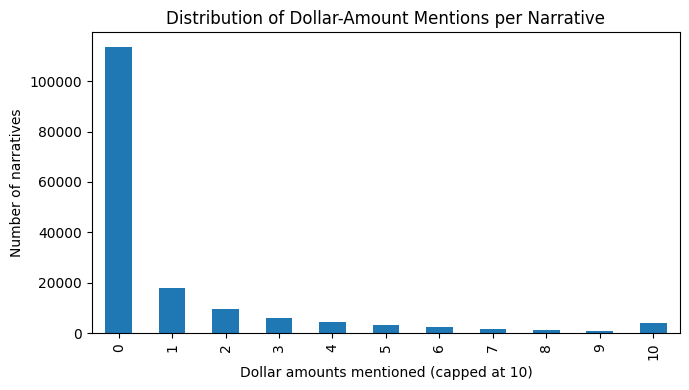

In [13]:
## load from previous saved output if necessary
# df = pd.read_csv("data/complaints_credit_reporting_with_entities.csv", low_memory=False)

df['dollar_amount_count'] = df['money_regex'].apply(len)
df['has_dollar_amount'] = df['dollar_amount_count'] > 0
df['org_count'] = df['orgs'].apply(len)
df['has_org'] = df['org_count'] > 0

print(f"Narratives mentioning at least one dollar amount: {df['has_dollar_amount'].mean():.1%}")
print(f"Narratives mentioning at least one org: {df['has_org'].mean():.1%}")
print(f"Mean dollar amounts per narrative (where present): {df.loc[df['has_dollar_amount'], 'dollar_amount_count'].mean():.1f}")

plt.figure(figsize=(7, 4))
df['dollar_amount_count'].clip(upper=10).value_counts().sort_index().plot(kind='bar')
plt.xlabel('Dollar amounts mentioned (capped at 10)')
plt.ylabel('Number of narratives')
plt.title('Distribution of Dollar-Amount Mentions per Narrative')
plt.tight_layout()
plt.show()


## Confirming DATE Coverage on the Full Corpus


The 47.0% DATE hit rate so far only came from the 200-narrative sample check, before the full batch extraction existed. Recomputing it on all 164,533 narratives now that df['dates'] is populated, so all three coverage numbers (dollar amount, ORG raw, DATE) are confirmed on the full corpus before I go digging into ORG filtering.

In [25]:
df['has_date'] = df['dates'].apply(len) > 0
print(f"Narratives with a spaCy DATE entity (full corpus): {df['has_date'].mean():.1%}")


Narratives with a spaCy DATE entity (full corpus): 47.4%


Full-corpus result: 47.4%, close to the 200-narrative sample's 47.0% — the sample held up here, same as it did for dollar amounts and ORG.

## Most Frequently Mentioned Organizations

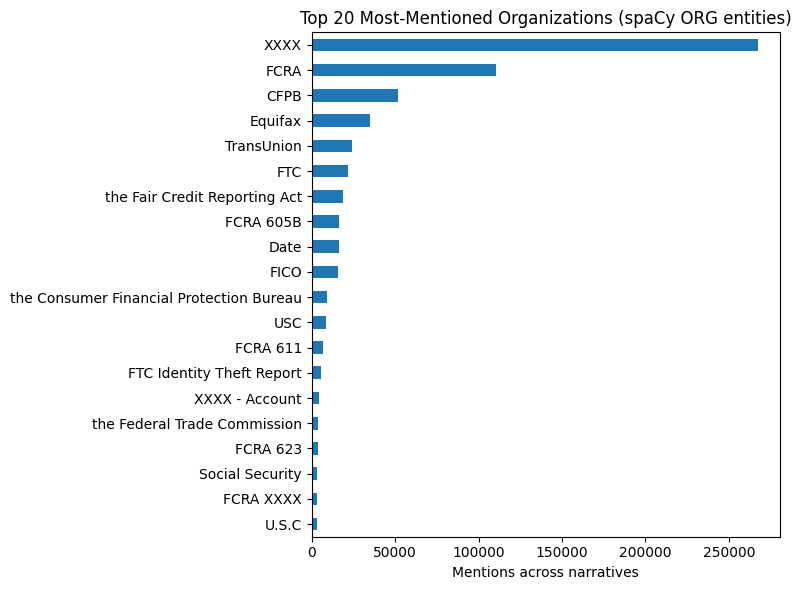

In [12]:
from collections import Counter

all_orgs = Counter(org for org_list in df['orgs'] for org in org_list)
top_orgs = pd.Series(dict(all_orgs.most_common(20)))

plt.figure(figsize=(8, 6))
top_orgs.sort_values().plot(kind='barh')
plt.xlabel('Mentions across narratives')
plt.title('Top 20 Most-Mentioned Organizations (spaCy ORG entities)')
plt.tight_layout()
plt.show()


## Quantifying the False-Positive Problem

Before writing up what's wrong with the raw ORG extraction, measuring it directly rather than describing it qualitatively.

In [15]:
# XXXX is CFPB's redaction placeholder, not an organization -- spaCy mistags it due to capitalization.
# Legal/regulatory terms (FCRA, CFPB, FTC, statute citations) are real ORG-shaped entities but
# represent which law/agency is being invoked, not which company the complaint is about --
# keeping these separate from genuine company mentions.
NON_COMPANY_ORGS = {
    'XXXX', 'FCRA', 'CFPB', 'FTC', 'USC', 'U.S.C',
    'the Fair Credit Reporting Act', 'FCRA 605B', 'FCRA 611', 'FCRA 623', 'FCRA XXXX',
    'the Consumer Financial Protection Bureau', 'the Federal Trade Commission',
    'FTC Identity Theft Report', 'Date', 'XXXX - Account', 'Social Security',
}

all_org_mentions_flat = [org for org_list in df['orgs'] for org in org_list]
non_company_hits = sum(1 for org in all_org_mentions_flat if org.strip() in NON_COMPANY_ORGS)
total_org_mentions = len(all_org_mentions_flat)
print(f"Redaction/legal-term false positives: {non_company_hits:,} of {total_org_mentions:,} "
      f"total ORG mentions ({non_company_hits/total_org_mentions:.1%})")

top_20_orgs = [org for org, _ in all_orgs.most_common(20)]
false_positives_in_top_20 = sum(1 for org in top_20_orgs if org in NON_COMPANY_ORGS)
print(f"Of the top 20 most-mentioned ORG entities, {false_positives_in_top_20} are redaction "
      f"artifacts or legal/regulatory terms, not companies")


Redaction/legal-term false positives: 554,139 of 876,401 total ORG mentions (63.2%)
Of the top 20 most-mentioned ORG entities, 17 are redaction artifacts or legal/regulatory terms, not companies


**Quantified result:** 554,139 of 876,401 total ORG mentions (63.2%) are redaction artifacts or legal/regulatory terms, not companies — 17 of the top 20 most-mentioned ORG entities fall into this category. The raw `org_count`/`has_org` columns are mostly measuring "does this narrative cite the FCRA," not "does it name a company."

## Results, and a False-Positive Problem I Need to Fix

30.9% of narratives mention at least one dollar amount (mean 3.7 where present), and 79.5% mention at least one ORG entity — both close to my 200-narrative sample check, so that sample was representative. But given the quantified false-positive rate above, has_org/org_count aren't usable as a "mentions a company" feature as-is. Fixing this next.

Narratives mentioning at least one real company (excluding redaction/legal terms): 56.5%
Mean company mentions per narrative (where present): 3.5


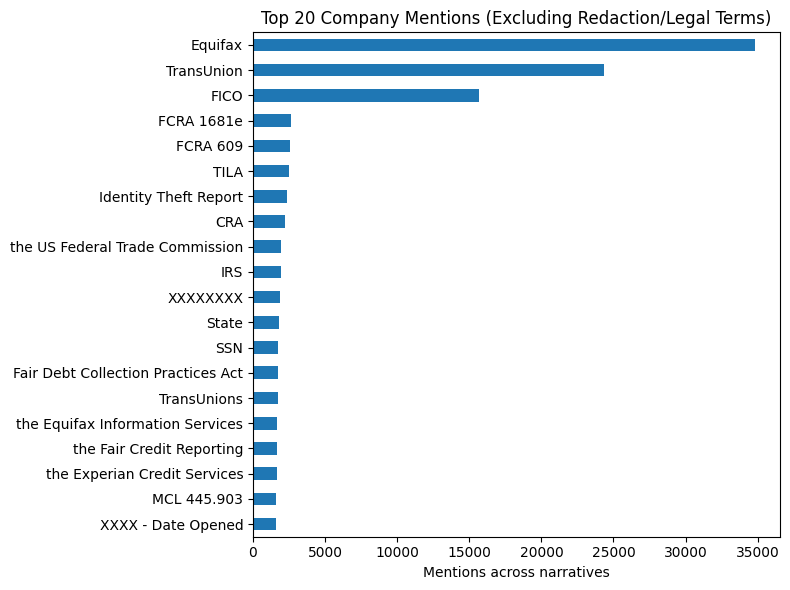

In [16]:
def is_company_org(org_text):
    return org_text.strip() not in NON_COMPANY_ORGS

df['company_orgs'] = df['orgs'].apply(lambda org_list: [o for o in org_list if is_company_org(o)])
df['company_org_count'] = df['company_orgs'].apply(len)
df['has_company_org'] = df['company_org_count'] > 0

print(f"Narratives mentioning at least one real company (excluding redaction/legal terms): "
      f"{df['has_company_org'].mean():.1%}")
print(f"Mean company mentions per narrative (where present): "
      f"{df.loc[df['has_company_org'], 'company_org_count'].mean():.1f}")

all_company_orgs = Counter(org for org_list in df['company_orgs'] for org in org_list)
top_company_orgs = pd.Series(dict(all_company_orgs.most_common(20)))

plt.figure(figsize=(8, 6))
top_company_orgs.sort_values().plot(kind='barh')
plt.xlabel('Mentions across narratives')
plt.title('Top 20 Company Mentions (Excluding Redaction/Legal Terms)')
plt.tight_layout()
plt.show()


**Blocklist result: 56.5% company-mention rate, but the chart is still messy** — `FCRA 1681e`, `TILA`, `the US Federal Trade Commission`, `XXXXXXXX` (different X-count than my exact `XXXX` match) all leak through. An exact-match blocklist can't keep up with how many surface variants spaCy produces for the same non-company concept. Switching to pattern-based rules.

Narratives mentioning at least one real company: 50.5%
Mean company mentions per narrative (where present): 2.9


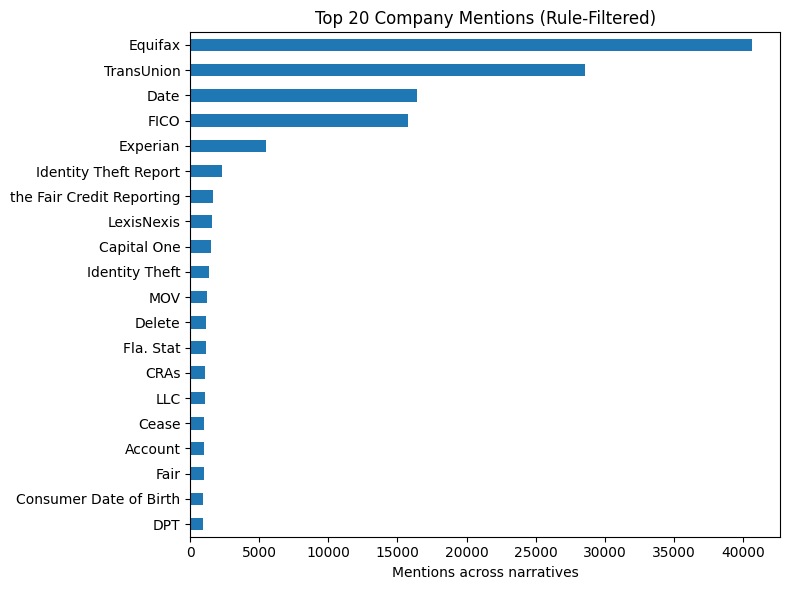

In [19]:
import re

LEGAL_KEYWORDS = re.compile(
    r'\b(FCRA|FDCPA|TILA|USC|U\.S\.C|CRA|Act|MCL\s*\d|IRS|SSN|State)\b'
    r'|\d{3,4}[a-z]?\b'  # bare statute-section numbers like 1681e, 609
    , re.IGNORECASE
)

GOV_AGENCY_KEYWORDS = re.compile(
    r'Federal Trade Commission|Consumer Financial Protection Bureau|Social Security|FTC|CFPB',
    re.IGNORECASE
)

REDACTION_PATTERN = re.compile(r'X{3,}')  # catches any run of 3+ X's, regardless of exact length

# Known bureaus/companies, normalized to a canonical name -- catches variant phrasing
# ("the Equifax Information Services", "TransUnions") that exact-match missed
COMPANY_ALIASES = {
    'equifax': 'Equifax',
    'transunion': 'TransUnion',
    'experian': 'Experian',
    'fico': 'FICO',
}

def classify_org(org_text):
    text = org_text.strip()
    if REDACTION_PATTERN.search(text):
        return None  # redaction artifact
    if GOV_AGENCY_KEYWORDS.search(text):
        return None  # government agency
    if LEGAL_KEYWORDS.search(text):
        return None  # statute/legal citation
    lowered = text.lower()
    for alias, canonical in COMPANY_ALIASES.items():
        if alias in lowered:
            return canonical
    return text  # keep as-is: unrecognized but not matching any exclusion rule

df['company_orgs'] = df['orgs'].apply(lambda org_list: [c for o in org_list if (c := classify_org(o)) is not None])
df['company_org_count'] = df['company_orgs'].apply(len)
df['has_company_org'] = df['company_org_count'] > 0

print(f"Narratives mentioning at least one real company: {df['has_company_org'].mean():.1%}")
print(f"Mean company mentions per narrative (where present): {df.loc[df['has_company_org'], 'company_org_count'].mean():.1f}")

all_company_orgs = Counter(org for org_list in df['company_orgs'] for org in org_list)
top_company_orgs = pd.Series(dict(all_company_orgs.most_common(20)))

plt.figure(figsize=(8, 6))
top_company_orgs.sort_values().plot(kind='barh')
plt.xlabel('Mentions across narratives')
plt.title('Top 20 Company Mentions (Rule-Filtered)')
plt.tight_layout()
plt.show()

**Rules result: 50.5%, still messy** (`Date`, `Identity Theft Report`, `TransUnions`, `the Equifax Information Services` — some noise slipping through, some real companies wrongly excluded by exact-name mismatches). Rather than keep guessing at more regex rules, using the dataset's own `Company` field as ground truth for what a real company name actually looks like.

Narratives mentioning at least one real company: 50.2%
Mean company mentions per narrative (where present): 2.5


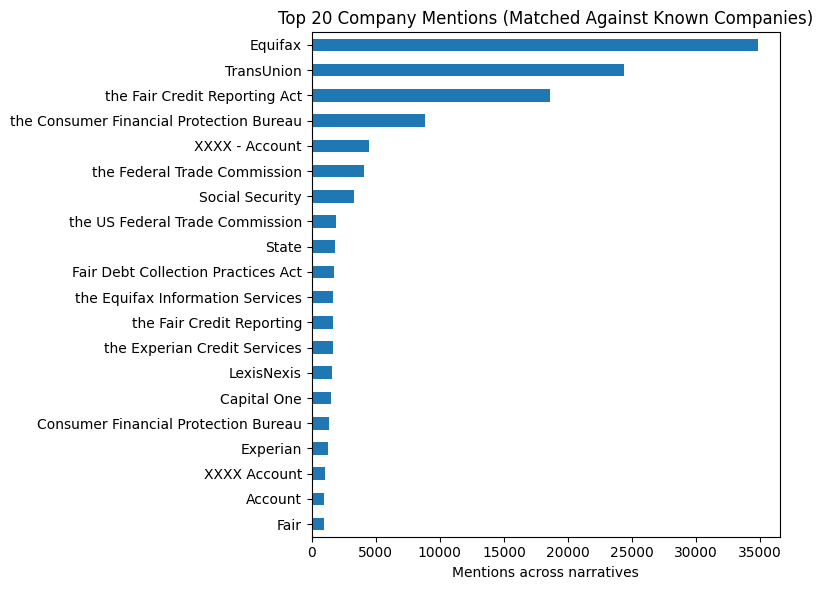

In [20]:
# Ground truth company names from the dataset itself, normalized for loose matching
known_companies = df['Company'].dropna().unique()
known_companies_lower = set(c.lower() for c in known_companies)

# Also pull out individual significant words from company names (e.g. "EQUIFAX" from
# "EQUIFAX, INC.") since spaCy's extracted text won't match the full official name exactly
company_keywords = set()
for c in known_companies:
    for word in re.findall(r'[A-Za-z]{4,}', c):
        company_keywords.add(word.lower())

def is_known_company(org_text):
    lowered = org_text.strip().lower()
    if lowered in known_companies_lower:
        return True
    # substring/keyword match: does this ORG text share a distinctive word with a real company name?
    org_words = set(re.findall(r'[A-Za-z]{4,}', org_text))
    return any(w.lower() in company_keywords for w in org_words)

df['company_orgs'] = df['orgs'].apply(lambda org_list: [o for o in org_list if is_known_company(o)])
df['company_org_count'] = df['company_orgs'].apply(len)
df['has_company_org'] = df['company_org_count'] > 0

print(f"Narratives mentioning at least one real company: {df['has_company_org'].mean():.1%}")
print(f"Mean company mentions per narrative (where present): {df.loc[df['has_company_org'], 'company_org_count'].mean():.1f}")

all_company_orgs = Counter(org for org_list in df['company_orgs'] for org in org_list)
top_company_orgs = pd.Series(dict(all_company_orgs.most_common(20)))

plt.figure(figsize=(8, 6))
top_company_orgs.sort_values().plot(kind='barh')
plt.xlabel('Mentions across narratives')
plt.title('Top 20 Company Mentions (Matched Against Known Companies)')
plt.tight_layout()
plt.show()

**Keyword-overlap result: 50.2%, new failure mode.** Generic words like "Services," "Bureau," and "Commission" appear in hundreds of company names, so matching on *any* shared word let legal/agency phrases sharing that vocabulary through (`the Fair Credit Reporting Act` matched via "Reporting"). Fix: weight words by how many distinct companies they actually appear in, not just whether they appear at all.

Kept 934 of 984 words as distinctive (appearing in 5 or fewer companies)
Narratives mentioning at least one real company: 43.9%
Mean company mentions per narrative (where present): 2.2


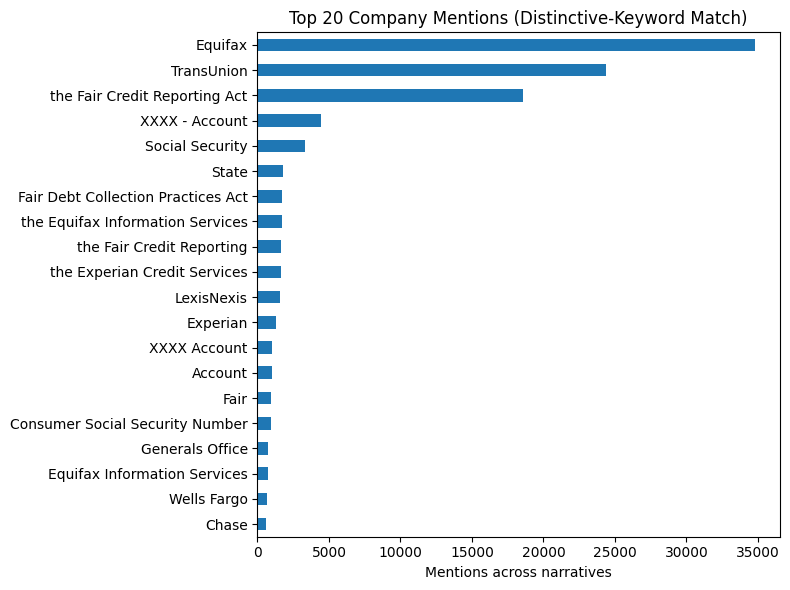

In [21]:
from collections import defaultdict

# For each word, count how many DISTINCT companies it appears in -- not how many times
# it appears overall, since a word could be rare in frequency but still generic in meaning.
word_to_companies = defaultdict(set)
for c in known_companies:
    for word in set(re.findall(r'[A-Za-z]{4,}', c.lower())):
        word_to_companies[word].add(c)

# Keep only words distinctive to a small number of companies (tune this threshold if needed)
DISTINCTIVENESS_THRESHOLD = 5
distinctive_keywords = {w for w, companies in word_to_companies.items() if len(companies) <= DISTINCTIVENESS_THRESHOLD}

print(f"Kept {len(distinctive_keywords):,} of {len(word_to_companies):,} words as distinctive "
      f"(appearing in {DISTINCTIVENESS_THRESHOLD} or fewer companies)")

def is_known_company(org_text):
    lowered = org_text.strip().lower()
    if lowered in known_companies_lower:
        return True
    org_words = set(re.findall(r'[A-Za-z]{4,}', org_text.lower()))
    return any(w in distinctive_keywords for w in org_words)

df['company_orgs'] = df['orgs'].apply(lambda org_list: [o for o in org_list if is_known_company(o)])
df['company_org_count'] = df['company_orgs'].apply(len)
df['has_company_org'] = df['company_org_count'] > 0

print(f"Narratives mentioning at least one real company: {df['has_company_org'].mean():.1%}")
print(f"Mean company mentions per narrative (where present): {df.loc[df['has_company_org'], 'company_org_count'].mean():.1f}")

all_company_orgs = Counter(org for org_list in df['company_orgs'] for org in org_list)
top_company_orgs = pd.Series(dict(all_company_orgs.most_common(20)))

plt.figure(figsize=(8, 6))
top_company_orgs.sort_values().plot(kind='barh')
plt.xlabel('Mentions across narratives')
plt.title('Top 20 Company Mentions (Distinctive-Keyword Match)')
plt.tight_layout()
plt.show()

**Distinctiveness result: 43.9%, barely changed anything** — 934 of 984 words survived the threshold. This dataset simply doesn't have enough distinct `Company` values for "how many companies use this word" to separate generic from distinctive vocabulary; the whole premise assumed more variety than the data has.

Stepping back: I've been asking "is this ORG text *any* company in the dataset" — a hard, open-ended matching problem, and three attempts at it haven't held up. Narrower, better-grounded question: for *this specific complaint*, does the narrative mention the company CFPB logged it against? Each row has its own `Company` field — I only need to check this row's entities against this row's own company, not the whole dataset's vocabulary. It's also a more meaningful feature: "did the complainant name the company they're complaining about" is more interpretable than a generic "any company mentioned" count.

In [22]:
def company_name_words(company_str):
    return set(re.findall(r'[A-Za-z]{4,}', str(company_str).lower()))

def org_matches_own_company(org_list, company_str):
    target_words = company_name_words(company_str)
    if not target_words:
        return []
    matches = []
    for org in org_list:
        org_words = set(re.findall(r'[A-Za-z]{4,}', org.lower()))
        if org_words & target_words:
            matches.append(org)
    return matches

df['company_orgs'] = df.apply(lambda row: org_matches_own_company(row['orgs'], row['Company']), axis=1)
df['company_org_count'] = df['company_orgs'].apply(len)
df['has_company_org'] = df['company_org_count'] > 0

print(f"Narratives that name the company they're complaining about: {df['has_company_org'].mean():.1%}")
print(f"Mean self-matched company mentions per narrative (where present): {df.loc[df['has_company_org'], 'company_org_count'].mean():.1f}")

# Spot-check: does this look right on a few examples?
sample_check = df[df['has_company_org']].sample(5, random_state=42)[['Company', 'company_orgs']]
sample_check

Narratives that name the company they're complaining about: 26.5%
Mean self-matched company mentions per narrative (where present): 1.9


,Company,company_orgs
91540,"EQUIFAX, INC.","[Equifax, Equifax, Equifax, Equifax, Equifax, ..."
145236,PREFERRED CREDIT INC,"[Preferred Credit , Inc., Preferred Credit, Pr..."
135794,"EQUIFAX, INC.",[Equifax]
58207,"EQUIFAX, INC.","[Equifax, Equifax]"
27793,"TRANSUNION INTERMEDIATE HOLDINGS, INC.","[TransUnion, TransUnion]"


**Spot-check: this one holds up.** 26.5% of narratives name the company they're complaining about (mean 1.9 self-matched mentions where present) — lower than every earlier attempt, and that's expected: this asks a narrower, harder question than "mentions any company." Checked 5 examples directly against `Company` — all 5 correct, no legal citations or redaction artifacts. Four iterations (blocklist → rules → keyword overlap → distinctiveness weighting) before landing on row-level self-matching — each looked reasonable until checked against real examples. Lesson: spot-check extracted-feature output against source data immediately, not after trusting a clean-looking chart.

`has_company_org` (self-matched) and `company_org_count` are the versions going into Notebook 04.

## Before / After: One Cleaned Example

Picking a narrative where filtering actually changed something, using the final row-level self-matching approach — checking whether the extracted entities correspond to *this row's own* `Company` field, not just any company in the dataset.

In [23]:
example = df[df['org_count'] > df['company_org_count']].iloc[0]
print("BEFORE (raw ORG extraction):")
print(example['orgs'])
print("\nAFTER (company-filtered):")
print(example['company_orgs'])

BEFORE (raw ORG extraction):
['the Fair Credit Reporting Act', 'FCRA', 'FCRA']

AFTER (company-filtered):
[]


## Entity Extraction Summary

Dollar amounts were extracted with regex rather than spaCy's MONEY entity because formatted currency expressions (including CFPB's `{$1,200.00}` bracket convention) are more reliably matched by pattern than recognized by a general-purpose NER model.

| Entity | Coverage | Notes |
|---|---|---|
| Dollar amount (regex) | 30.9% | Reliable — regex isn't affected by redaction or NER false positives |
| ORG (raw) | 79.5% | Dominated by `XXXX` (redaction artifact) and legal/regulatory citations; not usable as-is |
| ORG (self-matched to row's own Company) | 26.5% | Does the narrative name the specific company CFPB logged the complaint against — went through 4 filtering approaches before landing here; see write-up above |
| DATE | 47.4% | Suppressed for specific dates by CFPB's `XX/XX/XXXX` masking; captures relative time language ("last month," "since 2019") instead — confirmed on the full corpus, matching the earlier 200-narrative sample estimate of 47.0% |


## What This Feeds Into

These extracted entities provide structured signals — organizations, monetary amounts, dates — that complement dense text representations (Notebook 02's topic labels, and whatever embeddings Notebook 04 uses for classification) rather than duplicating them. A topic model captures *what a narrative is broadly about*; these entity features capture *specific concrete facts* within it. These structured signals will be evaluated alongside topic features and transformer embeddings in Notebook 04 to determine whether they actually improve complaint classification performance — not assumed to help just because they exist. Candidate features:
- `has_dollar_amount`, `dollar_amount_count` — does mentioning a specific dollar figure correlate with company response outcome?
- `has_company_org`, `company_org_count` — does the narrative name the specific company CFPB logged the complaint against (26.5% of narratives do)? A row-level self-match against each complaint's own `Company` field, not a generic "any company mentioned" count.

**Next:** `04_classification_transformer_vs_distilled.ipynb`, opening with the natural next question in this sequence: do these extracted signals — topics, entities, or both — actually improve prediction, or does the raw text (or the structured fields alone) already capture what matters?

In [26]:
#save the files for future

df[['Complaint ID', 'has_dollar_amount', 'dollar_amount_count',
    'has_company_org', 'company_org_count', 'has_date']].to_csv(
    "data/03_complaints_entities_final.csv", index=False
)
print(f"Saved final entity features: {df.shape[0]:,} rows")

Saved final entity features: 164,533 rows
